# Improving Dodgers Attendance - Rachel Wantuch

In [87]:
import pandas as pd
import numpy as np

## Loading the Data
Below the data is loaded and we can take a glimpse at the first few rows.

In [88]:
df=pd.read_csv("dodgers-2022.csv")
df.head()

,month,day,attend,day_of_week,opponent,temp,skies,day_night,cap,shirt,fireworks,bobblehead
0,APR,10,56000,Tuesday,Pirates,67,Clear,Day,NO,NO,NO,NO
1,APR,11,29729,Wednesday,Pirates,58,Cloudy,Night,NO,NO,NO,NO
2,APR,12,28328,Thursday,Pirates,57,Cloudy,Night,NO,NO,NO,NO
3,APR,13,31601,Friday,Padres,54,Cloudy,Night,NO,NO,YES,NO
4,APR,14,46549,Saturday,Padres,57,Cloudy,Night,NO,NO,NO,NO


The data is pretty standard as far as data type goes. Numbers are integer types. Everything else is object type.

In [89]:
df.shape

(81, 12)

In [90]:
df.dtypes

month          object
day             int64
attend          int64
day_of_week    object
opponent       object
temp            int64
skies          object
day_night      object
cap            object
shirt          object
fireworks      object
bobblehead     object
dtype: object

Also good news is that there are no missing values in any of the rows.

In [91]:
df.isna().sum()

month          0
day            0
attend         0
day_of_week    0
opponent       0
temp           0
skies          0
day_night      0
cap            0
shirt          0
fireworks      0
bobblehead     0
dtype: int64

## Overall Trend
In this section Ic reate a new column using the month and day columns turning them into a time series.

In [92]:
from datetime import datetime
import matplotlib.pyplot as plt

In [93]:
df['day_str']=df['day'].astype(str)
df['month_day']=df['month']+' '+df['day_str']+ ' ' +'2025'
df["month_day_ts"]=pd.to_datetime(df['month_day'], format='%b %d %Y')

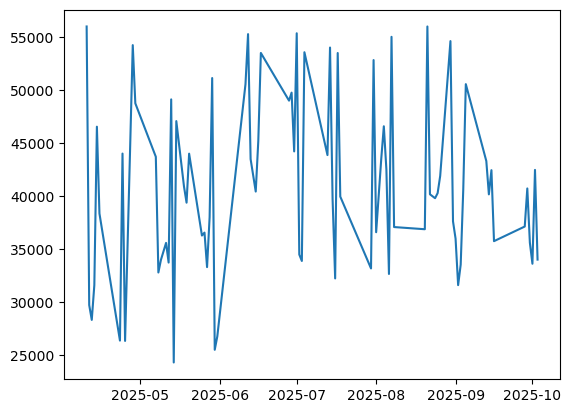

In [94]:
plt.plot(df['month_day_ts'],df['attend'])
plt.show()

This graph shows the volatility of attendance. There are many peaks and valleys and very few plateaus that would indicate a consistent level of attendance.

## Pie Chart - Attendance by Month
In changing the graph to a bar chart this will clean up the data so we can see what mnonths, if any, have better attendance.

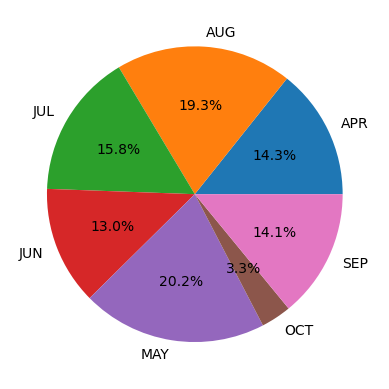

In [95]:
month_sum=df.groupby('month')['attend'].sum()
plt.pie(month_sum,labels=month_sum.index, autopct='%1.1f%%')
plt.show()

Now we see that May and August start to pull away as attendance leaders by month.

# First Variable-Temperature
The next few sections will perform univariate analyis before I move on to multivariate analysis.

I live in Southern California and I can tell you we are whimps with weather. We are spoiled and anything outside some unspoken temperature range decides if we go somewhere or not. Below I will visualize temper vs attendance to see if there is a trend.

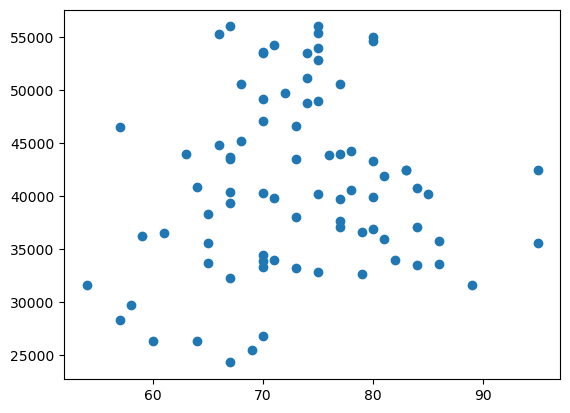

In [96]:
plt.scatter(df['temp'],df['attend'])
plt.show()

Interestingto note is that once the temp gets above 80 degrees farenheit attendance stays below 45,000. The sweet spot seems to be between mid 60s-mid 70s. Now predicting temperature isn't 100% all the time but my first recommendation would be to do a give away during hotter months.

## Second Variable - Promos
### Bobbleheads
First Let's look at if more people are influenced to come to a game if a bobblehead is given away. To do this I'll use box plots to compare the next few variables as games with promo vs games without promo. Typically there tend to be less games with promos so I expect the interquartile range to be smaller but if the variable did affect attendance I do expect the interquartile rnage to sit higher in attendance.

C:\Users\rwant\AppData\Local\Temp\ipykernel_22200\3708613920.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_bobble, yes_bobble], labels=['No','Yes'])


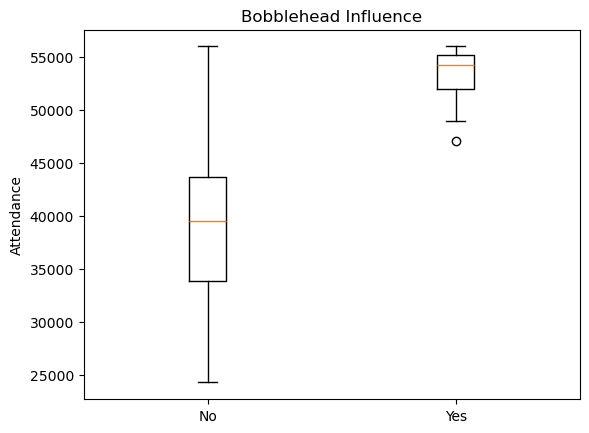

In [97]:
no_bobble=df[df['bobblehead']=='NO']['attend'].values
yes_bobble=df[df['bobblehead']=='YES']['attend'].values

plt.boxplot([no_bobble, yes_bobble], labels=['No','Yes'])
plt.ylabel("Attendance")
plt.title("Bobblehead Influence")
plt.show()

Overall bobbleheads appear to be a great indicator of higher attendance! There is one excpetion with a low outlier but ignoring that one game there is improvement in attendance!

## cap
The rest of the variables will examined with boxplots for this section.

C:\Users\rwant\AppData\Local\Temp\ipykernel_22200\757403001.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_cap, yes_cap], labels=['No','Yes'])


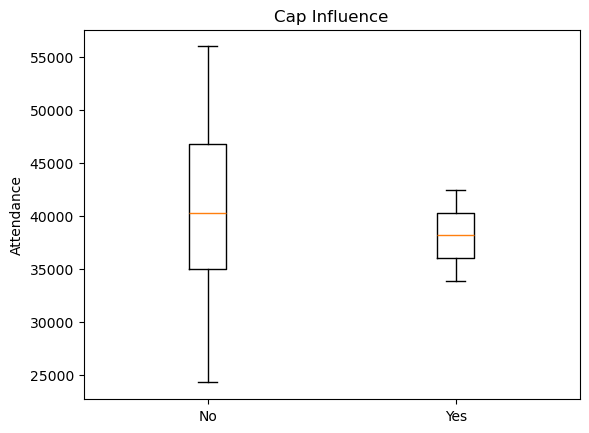

In [99]:
no_cap=df[df['cap']=='NO']['attend'].values
yes_cap=df[df['cap']=='YES']['attend'].values

plt.boxplot([no_cap, yes_cap], labels=['No','Yes'])
plt.ylabel("Attendance")
plt.title("Cap Influence")
plt.show()

This box plot shows that caps weren't motivating more people to show up to a game. In fact the interquartile range for cap giveaway games lies almost in the lower half of attendance for games when there are no cap giveaways.

## Shirt

C:\Users\rwant\AppData\Local\Temp\ipykernel_22200\3924352482.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_shirt, yes_shirt], labels=['No','Yes'])


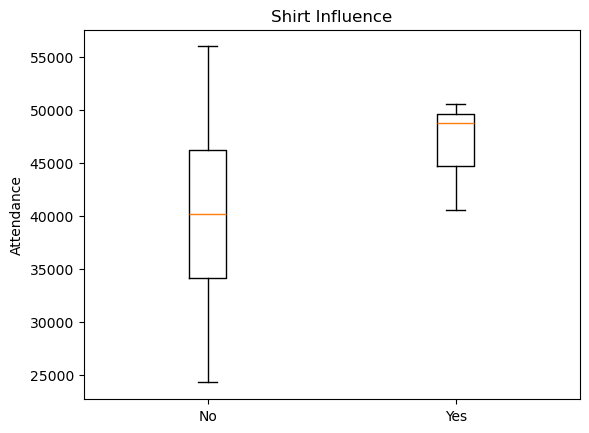

In [100]:
no_shirt=df[df['shirt']=='NO']['attend'].values
yes_shirt=df[df['shirt']=='YES']['attend'].values

plt.boxplot([no_shirt, yes_shirt], labels=['No','Yes'])
plt.ylabel("Attendance")
plt.title("Shirt Influence")
plt.show()

Shirt giveaways do bump up attedance! The interquartile range for shirt giveaway days sits close to the 75% mark for no shirt giveaway days showing that more people are showing up for a shirt.

## Fireworks

C:\Users\rwant\AppData\Local\Temp\ipykernel_22200\1102257371.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_fw, yes_fw], labels=['No','Yes'])


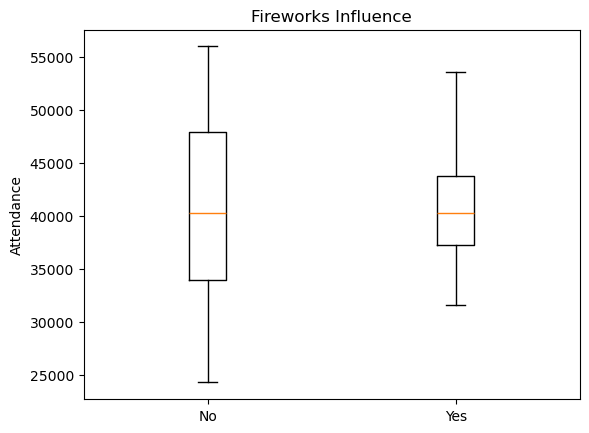

In [101]:
no_fw=df[df['fireworks']=='NO']['attend'].values
yes_fw=df[df['fireworks']=='YES']['attend'].values

plt.boxplot([no_fw, yes_fw], labels=['No','Yes'])
plt.ylabel("Attendance")
plt.title("Fireworks Influence")
plt.show()

Fireworks being offered didn't change attendance. The interquartile range for firework games is roughly the same as no firework games but just at a smalelr scale.

## Opponent

I'll create a dictionary for teams that assign to each color to be used in a scatterplot.

In [111]:
df['opponent'].unique()

array(['Pirates', 'Padres', 'Braves', 'Nationals', 'Giants', 'Rockies',
       'Snakes', 'Cardinals', 'Astros', 'Brewers', 'Angels', 'White Sox',
       'Mets', 'Reds', 'Phillies', 'Cubs', 'Marlins'], dtype=object)

In [145]:
colors_teams={'Pirates':'yellow', 'Padres':'chocolate','Braves': 'yellowgreen',
              'Nationals':'black','Giants':'orange','Rockies':'purple',
              'Snakes':'turquoise','Cardinals':'steelblue',
              'Astros':'sandybrown','Brewers':'gold','Angels':'red',
              'White Sox':'lightgray','Mets':'darkorange','Reds':'lime',
              'Phillies':'indigo','Cubs':'hotpink', 'Marlins':'slategrey'}

In [146]:
#to iterate through the list of opponents and assign a color
colors=[colors_teams[team] for team in df['opponent']]

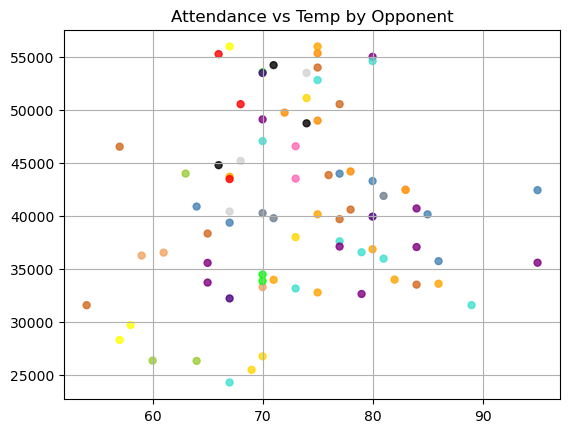

In [155]:
#Can't figure out the legend. I know I need a loop. but this code only returns te same color for every team or if I change color to color I only get grey dots witha  legend that is colored
#for team_name,color in colors_teams.items(): 
plt.scatter(df['temp'],df['attend'], c=colors, label=team_name, s=25, alpha=0.8) # Plot empty points for legend
plt.title('Attendance vs Temp by Opponent')
#plt.legend(title='Teams')
plt.grid(True)
plt.show()

In [156]:
df.loc[df['opponent']=='Pirates']

,month,day,attend,day_of_week,opponent,temp,skies,day_night,cap,shirt,fireworks,bobblehead,day_str,month_day,month_day_ts
0,APR,10,56000,Tuesday,Pirates,67,Clear,Day,NO,NO,NO,NO,10,APR 10 2025,2025-04-10
1,APR,11,29729,Wednesday,Pirates,58,Cloudy,Night,NO,NO,NO,NO,11,APR 11 2025,2025-04-11
2,APR,12,28328,Thursday,Pirates,57,Cloudy,Night,NO,NO,NO,NO,12,APR 12 2025,2025-04-12


I'm not sure we can say definitvely that the opponent dictates the attendance. For example, look at the Pirates games. There are two low attendance games and one basically full stadium game. All the variables that could possible affect the change are all very similar (no giveaways, similar temps, all weekdays). My only thought is that if this dataseet could include startng pitcher or score

## Ordinary Least Squared Model
Promo vs attendance for each model- It's time to put some actual numbers behind our visual observations above.

In [194]:
# turn all promos into dummy variables
df_dummies=pd.get_dummies(df,columns=['skies', 'day_night','cap','shirt','fireworks','bobblehead'],
                          drop_first=True)

In [195]:
import statsmodels.formula.api as smf

## Bobblehead

In [190]:
model=smf.ols('attend ~bobblehead_YES',data=df_dummies)
results=model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 attend   R-squared:                       0.339
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     40.44
Date:                Sat, 27 Sep 2025   Prob (F-statistic):           1.22e-08
Time:                        21:46:03   Log-Likelihood:                -828.61
No. Observations:                  81   AIC:                             1661.
Df Residuals:                      79   BIC:                             1666.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               3.91

Roughly 33% of the variance in attendance can be attributed to bobblehead giveaways. By looking at the intercept we can see that games without bobbleheads have a predicted average attendance of 39,140. The coefficient for the bobblehead tells us that bobbleheads should increase attendance for games by 14,010 people. This is also the only variable with a low P value showing a statisticall significant relationship.

Given the capacity of dodger stadium at 56,000 seats I would suggest bobbleheads on nights with opponents that aren't known for drawing big crowds.

## Shirt

In [191]:
model=smf.ols('attend ~shirt_YES',data=df_dummies)
results=model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 attend   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.428
Date:                Sat, 27 Sep 2025   Prob (F-statistic):              0.236
Time:                        21:47:15   Log-Likelihood:                -844.63
No. Observations:                  81   AIC:                             1693.
Df Residuals:                      79   BIC:                             1698.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          4.082e+04    937.00

Shirts are the next most inlfuencial factor. While not statistically significant we can see shirt giveaways could possibly given the game a little bump in attendance.

## Cap

In [192]:
model=smf.ols('attend ~cap_YES',data=df_dummies)
results=model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 attend   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.2397
Date:                Sat, 27 Sep 2025   Prob (F-statistic):              0.626
Time:                        21:49:26   Log-Likelihood:                -845.23
No. Observations:                  81   AIC:                             1694.
Df Residuals:                      79   BIC:                             1699.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        4.111e+04    938.014     

Caps don't affect attendance. It only explains 3% of the variance which is very small. Also notworthy is that this variable is so bad at being inlfuential that the model predicts less people would show up on cap giveaway nights.

## Fireworks

In [193]:
model=smf.ols('attend ~fireworks_YES',data=df_dummies)
results=model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 attend   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                 0.0003466
Date:                Sat, 27 Sep 2025   Prob (F-statistic):              0.985
Time:                        21:50:10   Log-Likelihood:                -845.35
No. Observations:                  81   AIC:                             1695.
Df Residuals:                      79   BIC:                             1699.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              4.103e+

Fireowkrsalso don't provide much influence to game attendance. The r2 is 0 which means no variance is explained by fireworks. The interesting part is the coefficient for it is 45 people. That is nothing in a stadium of 56,000 people.